In [153]:
################################################################################
# Author 1:      Lukas Umfahrer
# MatNr 1:       12337160
# Author 2:      Firstname Lastname
# MatNr 2:       01234567
# Author 3:      Firstname Lastname
# MatNr 3:       01234567
# File:          assignment2.ipynb
# Description: ... short description of the file ...
# Comments:    ... comments for the tutors ...
#              ... can be multiline ...
################################################################################


<center>
    <h1>Assignment 2</h1>
</center>

#### Imports

In [154]:
import pandas as pa
import matplotlib.pyplot as plt
import plotly as pl
import numpy as np
import pycountry as py
import pycountry_convert as pyco

## Part 1: Data Analysis & Visualization Code - Required Plots

### Line plots: Visualize data over time (4P)

In [155]:
data = pa.read_csv("OECD.ELS.HD,DSD_HEALTH_LVNG@DF_HEALTH_LVNG,+all.csv", delimiter = ",")   # reading data

In [156]:
def plot_alcohol_consumption(dataset: str, 
                             plot_title: str, 
                             x_label: str, 
                             y_label: str,
                             measure: str,
                             measure_type: str,
                             ref_area: str,
                             countries_list: list[str]) -> None:
      
        figure, axis = plt.subplots(figsize=(10,7))

        # using only alcohol consumption data
        data_alc = dataset[dataset[measure]==measure_type]

        # creating dict. with countries as key and color as value
        colors = ["blue", "orange", "green", "red"]
        country_colors = {countries_list[i]: colors[i] for i in range(len(countries_list))}


        for country in countries_list:
                # only using data from countries
                data_country = data_alc[data_alc[ref_area]==country]

                #calculating mean per year and country
                data_country_mean = data_country.groupby("TIME_PERIOD")["OBS_VALUE"].mean()
                ys_country = data_country_mean.values   # value
                xs_country = data_country_mean.index    # year
                axis.plot(xs_country, ys_country,
                          marker="o",
                          markersize="3",
                          markeredgecolor=country_colors[country],
                          label=country)


        axis.set_xlabel(x_label)
        axis.set_ylabel(y_label)
        axis.legend()
        plt.title(plot_title)
        plt.grid(True)


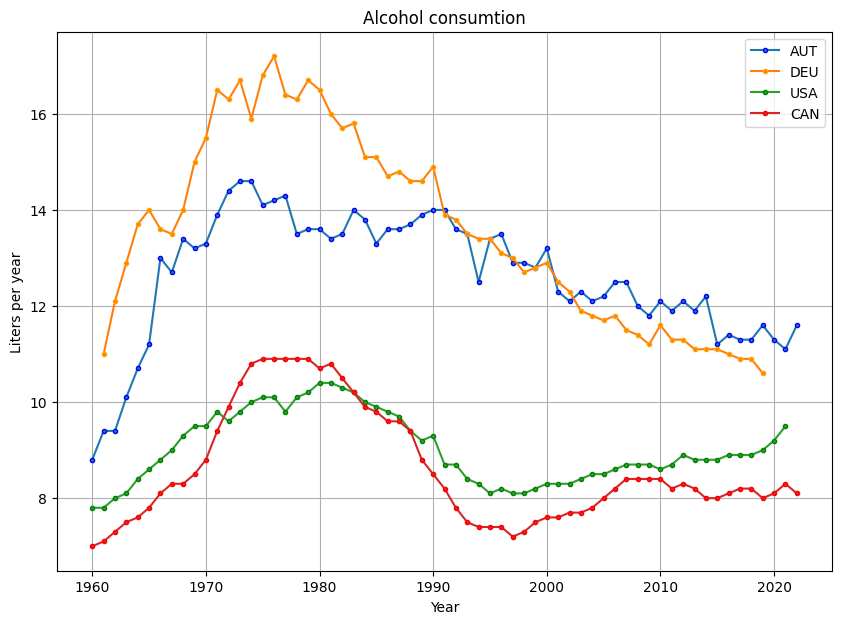

In [157]:
measure = "MEASURE"
measure_type = "AC"
ref_area = "REF_AREA"
countries_list = ["AUT", "DEU", "USA", "CAN"]

plot_alcohol_consumption(data,
                'Alcohol consumtion',
                'Year',
                'Liters per year',
                measure,
                measure_type,
                ref_area, 
                countries_list) 

### Bar charts: Compare data from different countries (4P)

In [158]:
def plot_overweight(dataset: str, 
                    plot_title: str, 
                    x_label: str, 
                    y_label: str,
                    countries: list[str],
                    period: list[int]) -> None:
    
   
    # using only data from following countries and a small time period
    data_country = dataset[dataset["REF_AREA"].isin(countries) & dataset["TIME_PERIOD"].isin(period)]

    # filtering sex (in dataset= M, F, _T)
    data_country_sex = data_country[data_country["SEX"].isin(["M", "F"])]

    # calculating mean gouped by countries and sex
    data_mean = data_country_sex.groupby(["REF_AREA", "SEX"])["OBS_VALUE"].mean().unstack()

    # plot
    ax = data_mean.plot(kind="bar", figsize=(10, 6), color=["pink", "blue"])
    

    plt.ylim(0, 100)
    plt.title(plot_title)
    plt.grid(True)
    plt.legend(title="SEX")
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

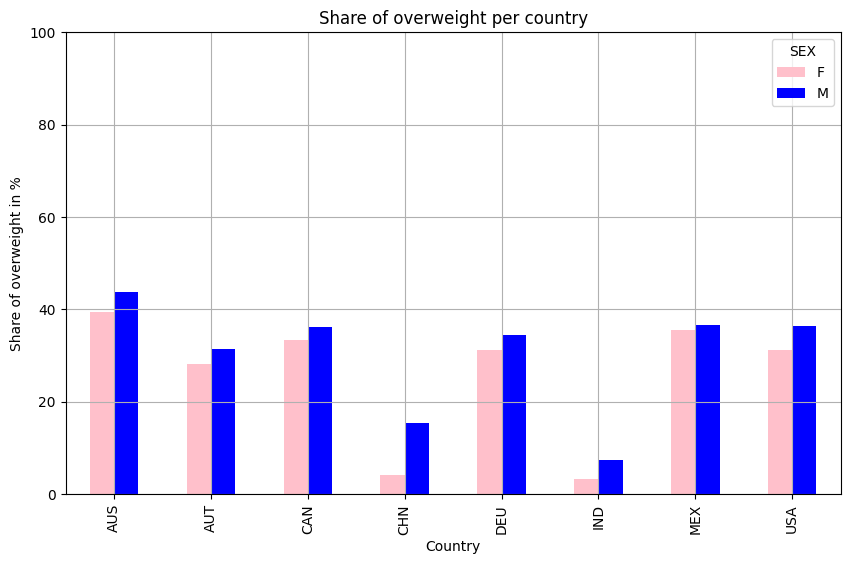

In [159]:
countries = ["AUT", "USA", "CHN", "AUS", "CAN", "DEU", "IND", "MEX"]
period = range(2000, 2023)

plot_overweight(data, 
                "Share of overweight per country",
                "Country",
                "Share of overweight in %",
                countries,
                period)

### Scatter plots: Visualize the relationship between different variables (7P)